# UrbanShift seasonal revenue and volume by industry

This notebook loads the four raw UrbanShift CSV files, cleans them inline, and plots monthly revenue and delivery volume patterns for each industry.

Purpose:
- Check whether revenue and volume patterns vary by industry.
- Identify whether customer-risk labels may be affected by seasonal or market-wide changes.
- Support decisions around relative churn target engineering.

## 1. Setup

Update `DATA_DIR` if your raw CSV files are stored somewhere else.

Expected files:
- `customers.csv`
- `couriers.csv`
- `deliveries.csv`
- `incidents.csv`

In [42]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)

DATA_DIR = Path("../data")

RAW_FILES = {
    "customers": DATA_DIR / "customers.csv",
    "couriers": DATA_DIR / "couriers.csv",
    "deliveries": DATA_DIR / "deliveries.csv",
    "incidents": DATA_DIR / "incidents.csv",
}

def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing required raw input file: {path}")
    return pd.read_csv(path)

customers_raw = load_csv(RAW_FILES["customers"])
couriers_raw = load_csv(RAW_FILES["couriers"])
deliveries_raw = load_csv(RAW_FILES["deliveries"])
incidents_raw = load_csv(RAW_FILES["incidents"])

raw_summary = pd.DataFrame([
    {"dataset": "customers", "rows": len(customers_raw), "columns": customers_raw.shape[1]},
    {"dataset": "couriers", "rows": len(couriers_raw), "columns": couriers_raw.shape[1]},
    {"dataset": "deliveries", "rows": len(deliveries_raw), "columns": deliveries_raw.shape[1]},
    {"dataset": "incidents", "rows": len(incidents_raw), "columns": incidents_raw.shape[1]},
])

print("Loaded raw files from:", DATA_DIR.resolve())
display(raw_summary)

Loaded raw files from: C:\Users\Ian_C\OneDrive\Desktop\Work\Project 4\urbanshift-bristol\data


,dataset,rows,columns
0,customers,120,8
1,couriers,65,5
2,deliveries,100110,8
3,incidents,22390,5


## 2. Validate required columns

In [43]:
REQUIRED_COLUMNS = {
    "customers": [
        "customer_id", "customer_name", "customer_size", "city", "signup_date",
        "account_manager", "industry", "payment_terms_days"
    ],
    "couriers": [
        "courier_id", "hire_date", "employment_type", "city", "shift_pattern"
    ],
    "deliveries": [
        "delivery_id", "delivery_date", "customer_id", "courier_id", "city",
        "time_taken_minutes", "delivery_status", "revenue_gbp"
    ],
    "incidents": [
        "incident_id", "delivery_id", "incident_date", "incident_type", "resolution_status"
    ],
}

raw_tables = {
    "customers": customers_raw,
    "couriers": couriers_raw,
    "deliveries": deliveries_raw,
    "incidents": incidents_raw,
}

missing = {
    name: sorted(set(cols) - set(raw_tables[name].columns))
    for name, cols in REQUIRED_COLUMNS.items()
}
missing = {name: cols for name, cols in missing.items() if cols}
if missing:
    raise ValueError(f"Missing required columns: {missing}")

def parse_mixed_dates(series: pd.Series) -> pd.Series:
    parsed = pd.to_datetime(series, errors="coerce")
    failed = parsed.isna() & series.notna()
    if failed.any():
        parsed_dayfirst = pd.to_datetime(series[failed], errors="coerce", dayfirst=True)
        parsed.loc[failed] = parsed_dayfirst
    return parsed

def standardise_city(series: pd.Series) -> pd.Series:
    return series.astype("string").str.strip().str.title()

customers = customers_raw.copy()
couriers = couriers_raw.copy()
deliveries = deliveries_raw.copy()
incidents = incidents_raw.copy()

for df in [customers, couriers, deliveries]:
    df["city"] = standardise_city(df["city"])

customers["signup_date"] = parse_mixed_dates(customers["signup_date"])
couriers["hire_date"] = parse_mixed_dates(couriers["hire_date"])
deliveries["delivery_date"] = parse_mixed_dates(deliveries["delivery_date"])
incidents["incident_date"] = parse_mixed_dates(incidents["incident_date"])

customers["payment_terms_days"] = pd.to_numeric(customers["payment_terms_days"], errors="coerce")
deliveries["time_taken_minutes"] = pd.to_numeric(deliveries["time_taken_minutes"], errors="coerce")
deliveries["revenue_gbp"] = pd.to_numeric(deliveries["revenue_gbp"], errors="coerce")

for df, cols in [
    (customers, ["customer_id", "customer_name", "customer_size", "account_manager", "industry"]),
    (couriers, ["courier_id", "employment_type", "shift_pattern"]),
    (deliveries, ["delivery_id", "customer_id", "courier_id", "delivery_status"]),
    (incidents, ["incident_id", "delivery_id", "incident_type", "resolution_status"]),
]:
    for col in cols:
        df[col] = df[col].astype("string").str.strip()

duplicate_delivery_rows = int(deliveries["delivery_id"].duplicated().sum())
deliveries = deliveries.drop_duplicates(subset=["delivery_id"], keep="first").copy()

missing_courier_rows = int(deliveries["courier_id"].isna().sum())
deliveries["courier_id"] = deliveries["courier_id"].fillna("SUBCONTRACTOR_UNKNOWN")

incidents["is_unmatched_delivery_id"] = ~incidents["delivery_id"].isin(deliveries["delivery_id"])
unmatched_incident_rows = int(incidents["is_unmatched_delivery_id"].sum())

invalid_delivery_dates = int(deliveries["delivery_date"].isna().sum())
if invalid_delivery_dates > 0:
    print(f"Warning: {invalid_delivery_dates} delivery rows have invalid dates and were excluded.")
deliveries = deliveries.dropna(subset=["delivery_date"]).copy()

deliveries["revenue_gbp"] = deliveries["revenue_gbp"].fillna(0)

cleaning_summary = pd.DataFrame([
    {"cleaning_step": "duplicate delivery_id rows removed", "rows_affected": duplicate_delivery_rows},
    {"cleaning_step": "missing courier_id values labelled SUBCONTRACTOR_UNKNOWN", "rows_affected": missing_courier_rows},
    {"cleaning_step": "incident delivery_id values flagged as unmatched", "rows_affected": unmatched_incident_rows},
    {"cleaning_step": "invalid delivery_date rows excluded", "rows_affected": invalid_delivery_dates},
])

print("Date range:", deliveries["delivery_date"].min(), "to", deliveries["delivery_date"].max())
display(cleaning_summary)

Date range: 2024-10-01 00:00:00 to 2025-06-30 00:00:00


,cleaning_step,rows_affected
0,duplicate delivery_id rows removed,1962
1,missing courier_id values labelled SUBCONTRACT...,3913
2,incident delivery_id values flagged as unmatched,5
3,invalid delivery_date rows excluded,0


## 3. Join deliveries to customer industry

The deliveries table is the central fact table, but industry is held in the customer table. This join allows revenue and volume seasonality to be analysed by industry.


In [44]:
delivery_industry = deliveries.merge(
    customers[["customer_id", "industry"]],
    on="customer_id",
    how="left"
)

missing_industry = delivery_industry["industry"].isna().sum()
print("Rows missing industry after join:", missing_industry)

delivery_industry["industry"] = delivery_industry["industry"].fillna("Unknown")

delivery_industry["month"] = delivery_industry["delivery_date"].dt.to_period("M").dt.to_timestamp()
delivery_industry["month_label"] = delivery_industry["month"].dt.strftime("%b %Y")

display(delivery_industry.head())

Rows missing industry after join: 0


,delivery_id,delivery_date,customer_id,courier_id,city,time_taken_minutes,delivery_status,revenue_gbp,industry,month,month_label
0,D0030927,2025-03-09,CUST1021,C2006,London,82,Delivered,3.7230,Fashion,2025-03-01,Mar 2025
1,D0053648,2024-12-01,CUST1053,C2024,Birmingham,50,Delivered,5.8500,Other,2024-12-01,Dec 2024
2,D0064301,2024-11-14,CUST1075,C2029,Manchester,32,Delivered,5.2615,Books,2024-11-01,Nov 2024
3,D0087733,2025-01-16,CUST1101,C2008,London,185,Delivered,6.2200,Food & Drink,2025-01-01,Jan 2025
4,D0021526,2024-11-21,CUST1020,C2057,Birmingham,92,Delivered,5.9200,Food & Drink,2024-11-01,Nov 2024


## 4. Monthly revenue and volume by industry

In [45]:
monthly_industry = (
    delivery_industry
    .groupby(["month", "industry"], as_index=False)
    .agg(
        revenue_gbp=("revenue_gbp", "sum"),
        delivery_volume=("delivery_id", "nunique"),
    )
    .sort_values(["industry", "month"])
)

monthly_industry["month_label"] = monthly_industry["month"].dt.strftime("%b %Y")

display(monthly_industry.head(20))

,month,industry,revenue_gbp,delivery_volume,month_label
0,2024-10-01,Beauty,8749.5105,1818,Oct 2024
7,2024-11-01,Beauty,8069.1060,1666,Nov 2024
14,2024-12-01,Beauty,7673.3460,1586,Dec 2024
21,2025-01-01,Beauty,4588.8240,960,Jan 2025
28,2025-02-01,Beauty,4602.0735,948,Feb 2025
35,2025-03-01,Beauty,5374.1975,1127,Mar 2025
42,2025-04-01,Beauty,5311.1345,1122,Apr 2025
49,2025-05-01,Beauty,4849.9295,1023,May 2025
56,2025-06-01,Beauty,4975.0115,1065,Jun 2025
1,2024-10-01,Books,5670.2795,1210,Oct 2024


## 5. Plot revenue trend for each industry

Each industry is plotted as a separate line on one chart so that seasonal differences can be visually compared.


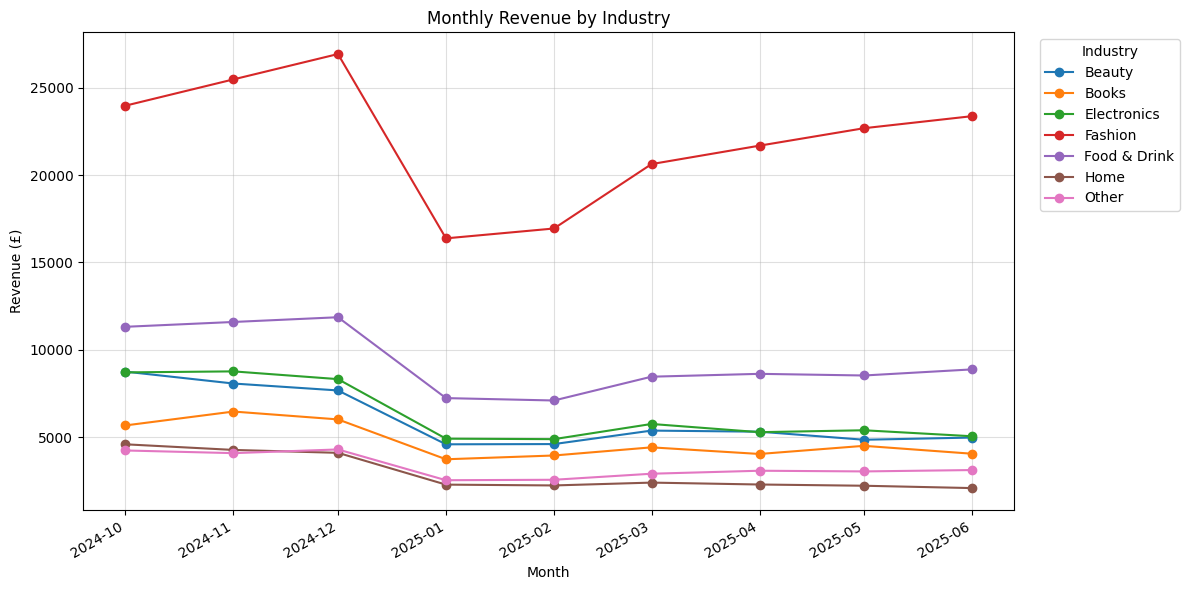

In [46]:
fig, ax = plt.subplots(figsize=(12, 6))

for industry, group in monthly_industry.groupby("industry"):
    group = group.sort_values("month")
    ax.plot(group["month"], group["revenue_gbp"], marker="o", label=industry)

ax.set_title("Monthly Revenue by Industry")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (£)")
ax.grid(True, alpha=0.4)
ax.legend(title="Industry", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 6. Plot delivery volume trend for each industry

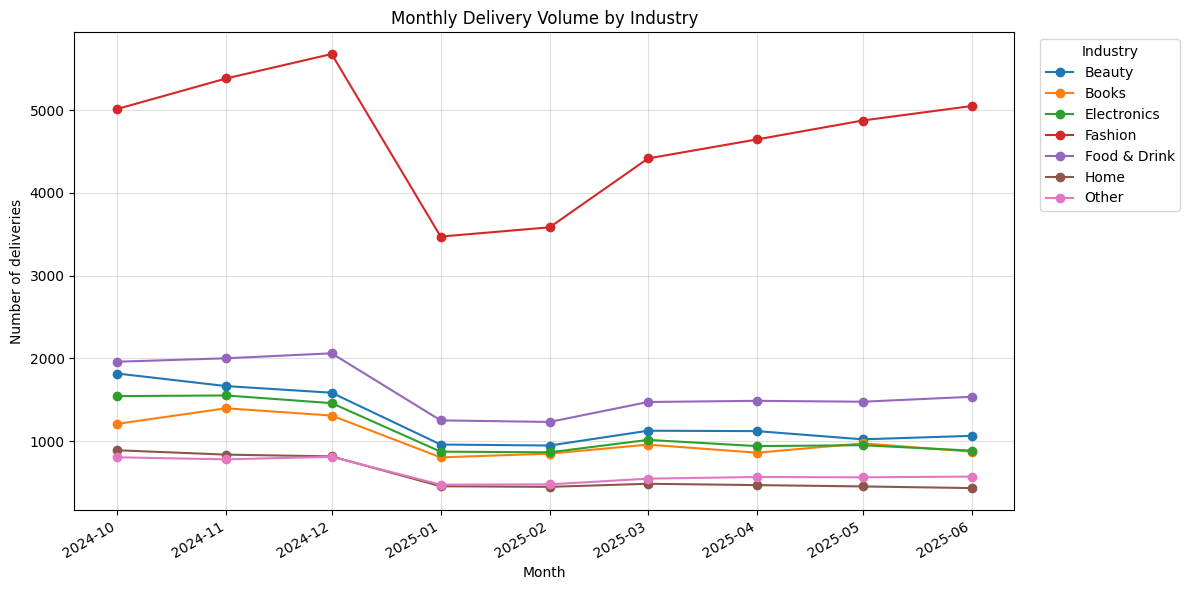

In [47]:
fig, ax = plt.subplots(figsize=(12, 6))

for industry, group in monthly_industry.groupby("industry"):
    group = group.sort_values("month")
    ax.plot(group["month"], group["delivery_volume"], marker="o", label=industry)

ax.set_title("Monthly Delivery Volume by Industry")
ax.set_xlabel("Month")
ax.set_ylabel("Number of deliveries")
ax.grid(True, alpha=0.4)
ax.legend(title="Industry", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 7. Normalised seasonal index by industry

Raw revenue and volume can be dominated by large industries. To compare seasonal shape, create an index where each industry's average monthly value equals 100.

Interpretation:
- 100 = typical month for that industry
- 120 = 20% above that industry's average
- 80 = 20% below that industry's average


In [48]:
monthly_industry["revenue_index"] = monthly_industry.groupby("industry")["revenue_gbp"].transform(
    lambda s: np.where(s.mean() == 0, np.nan, (s / s.mean()) * 100)
)

monthly_industry["volume_index"] = monthly_industry.groupby("industry")["delivery_volume"].transform(
    lambda s: np.where(s.mean() == 0, np.nan, (s / s.mean()) * 100)
)

display(monthly_industry.head(20))

,month,industry,revenue_gbp,delivery_volume,month_label,revenue_index,volume_index
0,2024-10-01,Beauty,8749.5105,1818,Oct 2024,145.305485,144.604507
7,2024-11-01,Beauty,8069.1060,1666,Nov 2024,134.005823,132.514361
14,2024-12-01,Beauty,7673.3460,1586,Dec 2024,127.433330,126.151127
21,2025-01-01,Beauty,4588.8240,960,Jan 2025,76.207840,76.358816
28,2025-02-01,Beauty,4602.0735,948,Feb 2025,76.427878,75.404331
35,2025-03-01,Beauty,5374.1975,1127,Mar 2025,89.250750,89.642068
42,2025-04-01,Beauty,5311.1345,1122,Apr 2025,88.203445,89.244366
49,2025-05-01,Beauty,4849.9295,1023,May 2025,80.544089,81.369863
56,2025-06-01,Beauty,4975.0115,1065,Jun 2025,82.621360,84.710561
1,2024-10-01,Books,5670.2795,1210,Oct 2024,119.147230,117.844389


## 8. Plot normalised revenue index by industry

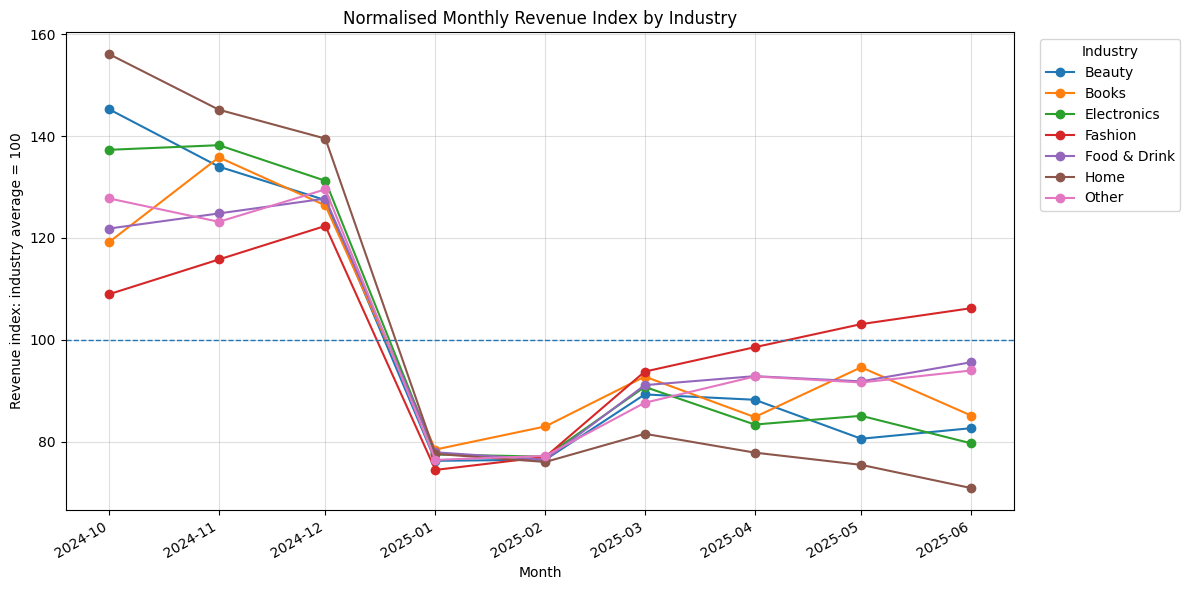

In [49]:
fig, ax = plt.subplots(figsize=(12, 6))

for industry, group in monthly_industry.groupby("industry"):
    group = group.sort_values("month")
    ax.plot(group["month"], group["revenue_index"], marker="o", label=industry)

ax.axhline(100, linestyle="--", linewidth=1)
ax.set_title("Normalised Monthly Revenue Index by Industry")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue index: industry average = 100")
ax.grid(True, alpha=0.4)
ax.legend(title="Industry", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 9. Plot normalised delivery volume index by industry

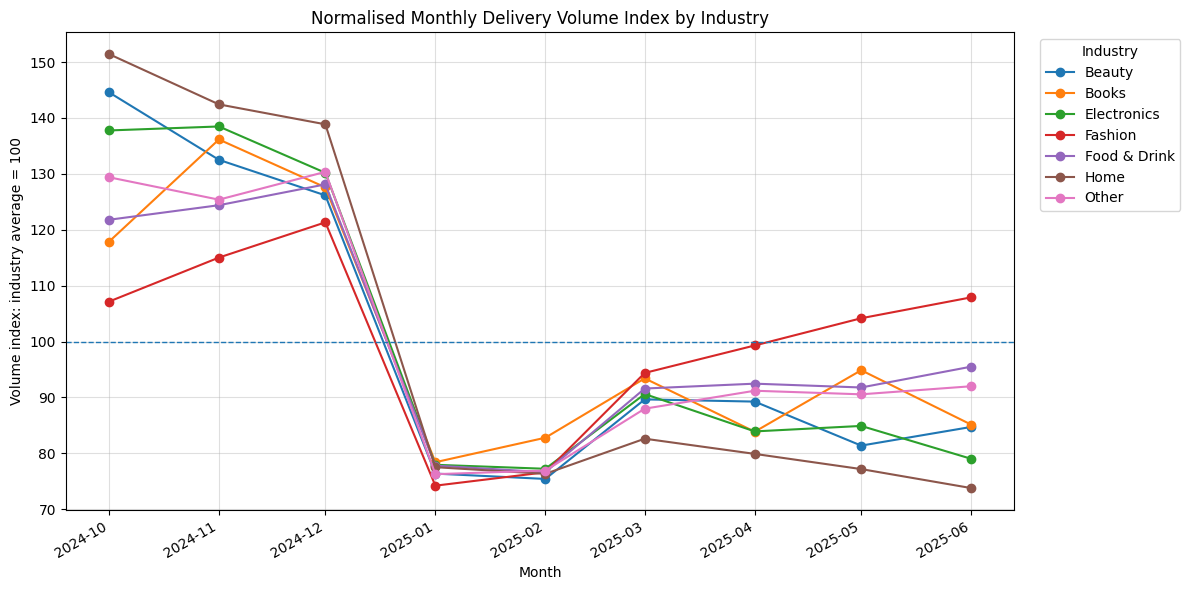

In [50]:
fig, ax = plt.subplots(figsize=(12, 6))

for industry, group in monthly_industry.groupby("industry"):
    group = group.sort_values("month")
    ax.plot(group["month"], group["volume_index"], marker="o", label=industry)

ax.axhline(100, linestyle="--", linewidth=1)
ax.set_title("Normalised Monthly Delivery Volume Index by Industry")
ax.set_xlabel("Month")
ax.set_ylabel("Volume index: industry average = 100")
ax.grid(True, alpha=0.4)
ax.legend(title="Industry", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 10. Summary table

This table highlights month-to-month variability by industry.

`revenue_cv` and `volume_cv` are coefficients of variation:
- Higher values imply more volatility across months.
- Lower values imply more stable monthly behaviour.

In [51]:
industry_seasonality_summary = (
    monthly_industry
    .groupby("industry")
    .agg(
        months_observed=("month", "nunique"),
        total_revenue=("revenue_gbp", "sum"),
        avg_monthly_revenue=("revenue_gbp", "mean"),
        revenue_std=("revenue_gbp", "std"),
        total_deliveries=("delivery_volume", "sum"),
        avg_monthly_deliveries=("delivery_volume", "mean"),
        volume_std=("delivery_volume", "std"),
    )
    .reset_index()
)

industry_seasonality_summary["revenue_cv"] = (
    industry_seasonality_summary["revenue_std"]
    / industry_seasonality_summary["avg_monthly_revenue"]
)

industry_seasonality_summary["volume_cv"] = (
    industry_seasonality_summary["volume_std"]
    / industry_seasonality_summary["avg_monthly_deliveries"]
)

industry_seasonality_summary = industry_seasonality_summary.sort_values(
    ["revenue_cv", "volume_cv"],
    ascending=False
)

display(industry_seasonality_summary)

,industry,months_observed,total_revenue,avg_monthly_revenue,revenue_std,total_deliveries,avg_monthly_deliveries,volume_std,revenue_cv,volume_cv
5,Home,9,26450.9200,2938.991111,1045.472844,5295,588.333333,196.689476,0.355725,0.334316
0,Beauty,9,54193.1330,6021.459222,1651.589924,11315,1257.222222,335.536428,0.274284,0.266887
2,Electronics,9,57068.2900,6340.921111,1717.108240,10093,1121.444444,303.019022,0.270798,0.270204
1,Books,9,42831.4745,4759.052722,1014.868550,9241,1026.777778,220.858992,0.213250,0.215099
6,Other,9,29834.2600,3314.917778,700.441617,5606,622.888889,137.588557,0.211300,0.220888
4,Food & Drink,9,83599.8200,9288.868889,1835.835058,14485,1609.444444,317.638990,0.197638,0.197359
3,Fashion,9,198117.1565,22013.017389,3568.243401,42113,4679.222222,750.235426,0.162097,0.160333


## 11. Interpretation guidance

When reviewing the plots, look for:

1. **Common market-wide patterns**  
   If most industries fall in the same months, this suggests a broad seasonal or market-wide effect.

2. **Industry-specific patterns**  
   If only one or two industries fall, this suggests sector-specific behaviour.

3. **Volume vs revenue divergence**  
   If volume falls but revenue does not, the customer mix or average delivery value may have changed.

4. **Implication for churn modelling**  
   If seasonal or market-wide effects are visible, a relative churn target is more appropriate than a purely absolute drop target.

## 12. Revenue and volume share by industry

The normalised index plots show how each industry performs relative to its own average.

This section adds a different view: each industry's **share of total UrbanShift revenue and delivery volume** each month.

Interpretation:
- Rising share means the industry is outperforming the wider business.
- Falling share means the industry is underperforming the wider business.
- This helps distinguish true industry/customer weakness from broad seasonal or market-wide movement.

In [52]:
# Monthly totals across all industries.
monthly_market_totals = (
    monthly_industry
    .groupby("month", as_index=False)
    .agg(
        total_market_revenue_gbp=("revenue_gbp", "sum"),
        total_market_delivery_volume=("delivery_volume", "sum"),
    )
)

relative_industry = monthly_industry.merge(
    monthly_market_totals,
    on="month",
    how="left"
)

relative_industry["revenue_share_pct"] = np.where(
    relative_industry["total_market_revenue_gbp"] == 0,
    np.nan,
    relative_industry["revenue_gbp"] / relative_industry["total_market_revenue_gbp"] * 100
)

relative_industry["volume_share_pct"] = np.where(
    relative_industry["total_market_delivery_volume"] == 0,
    np.nan,
    relative_industry["delivery_volume"] / relative_industry["total_market_delivery_volume"] * 100
)

display(relative_industry.head(20))

,month,industry,revenue_gbp,delivery_volume,month_label,revenue_index,volume_index,total_market_revenue_gbp,total_market_delivery_volume,revenue_share_pct,volume_share_pct
0,2024-10-01,Beauty,8749.5105,1818,Oct 2024,145.305485,144.604507,67248.2720,13243,13.010759,13.728007
1,2024-11-01,Beauty,8069.1060,1666,Nov 2024,134.005823,132.514361,68726.9090,13620,11.740825,12.232012
2,2024-12-01,Beauty,7673.3460,1586,Dec 2024,127.433330,126.151127,69204.6855,13724,11.087900,11.556398
3,2025-01-01,Beauty,4588.8240,960,Jan 2025,76.207840,76.358816,41660.7390,8294,11.014745,11.574632
4,2025-02-01,Beauty,4602.0735,948,Feb 2025,76.427878,75.404331,42269.7060,8409,10.887404,11.273635
5,2025-03-01,Beauty,5374.1975,1127,Mar 2025,89.250750,89.642068,49936.3890,10026,10.762087,11.240774
6,2025-04-01,Beauty,5311.1345,1122,Apr 2025,88.203445,89.244366,50306.5695,10096,10.557537,11.113312
7,2025-05-01,Beauty,4849.9295,1023,May 2025,80.544089,81.369863,51214.2240,10318,9.469888,9.914712
8,2025-06-01,Beauty,4975.0115,1065,Jun 2025,82.621360,84.710561,51527.5600,10418,9.655050,10.222691
9,2024-10-01,Books,5670.2795,1210,Oct 2024,119.147230,117.844389,67248.2720,13243,8.431859,9.136903


## 13. Plot revenue share by industry

This plot shows each industry's percentage contribution to total monthly revenue.

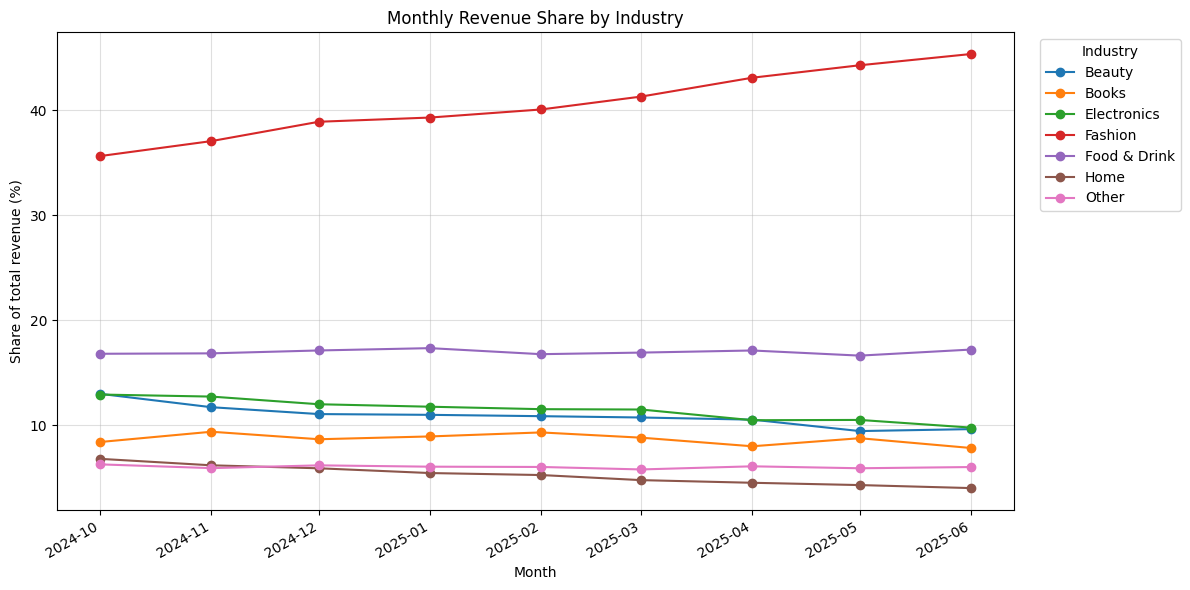

In [53]:
fig, ax = plt.subplots(figsize=(12, 6))

for industry, group in relative_industry.groupby("industry"):
    group = group.sort_values("month")
    ax.plot(group["month"], group["revenue_share_pct"], marker="o", label=industry)

ax.set_title("Monthly Revenue Share by Industry")
ax.set_xlabel("Month")
ax.set_ylabel("Share of total revenue (%)")
ax.grid(True, alpha=0.4)
ax.legend(title="Industry", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 14. Plot delivery volume share by industry

This plot shows each industry's percentage contribution to total monthly delivery volume.

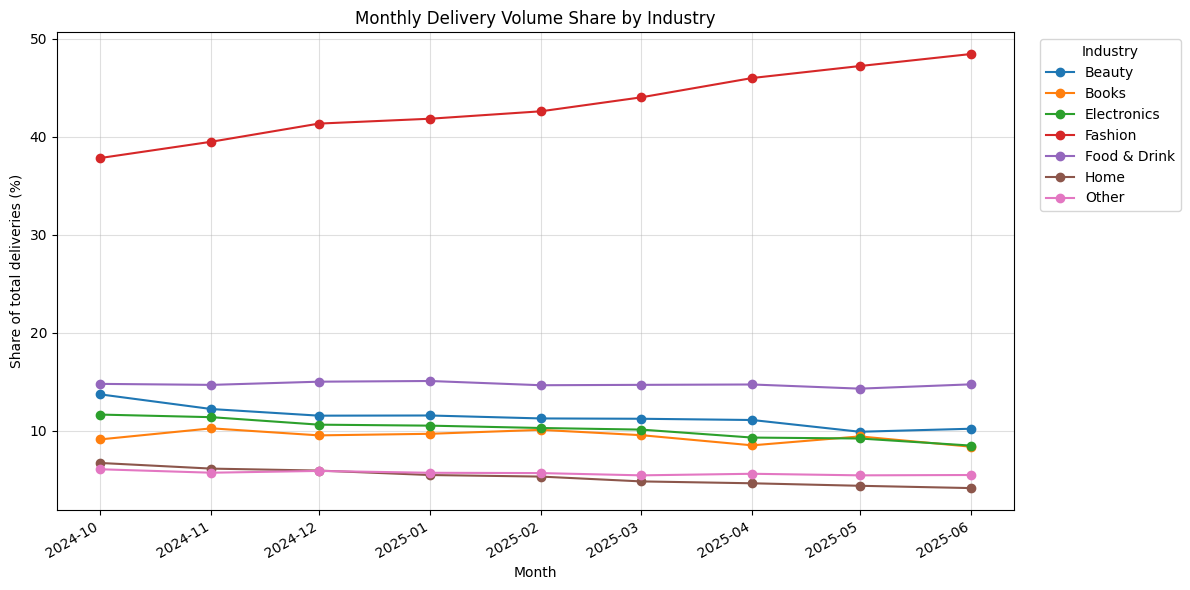

In [54]:
fig, ax = plt.subplots(figsize=(12, 6))

for industry, group in relative_industry.groupby("industry"):
    group = group.sort_values("month")
    ax.plot(group["month"], group["volume_share_pct"], marker="o", label=industry)

ax.set_title("Monthly Delivery Volume Share by Industry")
ax.set_xlabel("Month")
ax.set_ylabel("Share of total deliveries (%)")
ax.grid(True, alpha=0.4)
ax.legend(title="Industry", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 15. Industry relative strength

This section compares each industry's month-to-month growth against the overall market's month-to-month growth.

Formula:

```text
industry_relative_revenue_strength = industry_revenue_growth - market_revenue_growth
industry_relative_volume_strength = industry_volume_growth - market_volume_growth
```

Interpretation:
- `0` = industry moved with the market.
- Positive = industry outperformed the market.
- Negative = industry underperformed the market.

This mirrors the logic of the relative churn target used in the ML pipeline.

In [55]:
relative_industry = relative_industry.sort_values(["industry", "month"]).copy()

# Industry-level month-on-month growth.
relative_industry["industry_revenue_growth_pct"] = (
    relative_industry
    .groupby("industry")["revenue_gbp"]
    .pct_change()
    * 100
)

relative_industry["industry_volume_growth_pct"] = (
    relative_industry
    .groupby("industry")["delivery_volume"]
    .pct_change()
    * 100
)

# Market-level month-on-month growth.
monthly_market_totals = monthly_market_totals.sort_values("month").copy()
monthly_market_totals["market_revenue_growth_pct"] = (
    monthly_market_totals["total_market_revenue_gbp"].pct_change() * 100
)
monthly_market_totals["market_volume_growth_pct"] = (
    monthly_market_totals["total_market_delivery_volume"].pct_change() * 100
)

relative_industry = relative_industry.merge(
    monthly_market_totals[[
        "month",
        "market_revenue_growth_pct",
        "market_volume_growth_pct",
    ]],
    on="month",
    how="left"
)

relative_industry["relative_revenue_strength_pct"] = (
    relative_industry["industry_revenue_growth_pct"]
    - relative_industry["market_revenue_growth_pct"]
)

relative_industry["relative_volume_strength_pct"] = (
    relative_industry["industry_volume_growth_pct"]
    - relative_industry["market_volume_growth_pct"]
)

display(relative_industry[[
    "month",
    "industry",
    "industry_revenue_growth_pct",
    "market_revenue_growth_pct",
    "relative_revenue_strength_pct",
    "industry_volume_growth_pct",
    "market_volume_growth_pct",
    "relative_volume_strength_pct",
]].head(30))

,month,industry,industry_revenue_growth_pct,market_revenue_growth_pct,relative_revenue_strength_pct,industry_volume_growth_pct,market_volume_growth_pct,relative_volume_strength_pct
0,2024-10-01,Beauty,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-01,Beauty,-7.776486,2.198773,-9.975260,-8.360836,2.846787,-11.207623
2,2024-12-01,Beauty,-4.904633,0.695181,-5.599814,-4.801921,0.763583,-5.565504
3,2025-01-01,Beauty,-40.197875,-39.800696,-0.397179,-39.470366,-39.565724,0.095359
4,2025-02-01,Beauty,0.288734,1.461729,-1.172995,-1.250000,1.386544,-2.636544
5,2025-03-01,Beauty,16.777742,18.137536,-1.359794,18.881857,19.229397,-0.347541
6,2025-04-01,Beauty,-1.173440,0.741304,-1.914744,-0.443656,0.698185,-1.141840
7,2025-05-01,Beauty,-8.683738,1.804246,-10.487984,-8.823529,2.198891,-11.022420
8,2025-06-01,Beauty,2.579048,0.611814,1.967233,4.105572,0.969180,3.136392
9,2024-10-01,Books,NaN,NaN,NaN,NaN,NaN,NaN


## 16. Plot relative revenue strength by industry

This plot shows whether each industry is growing or declining faster than the market in revenue terms.

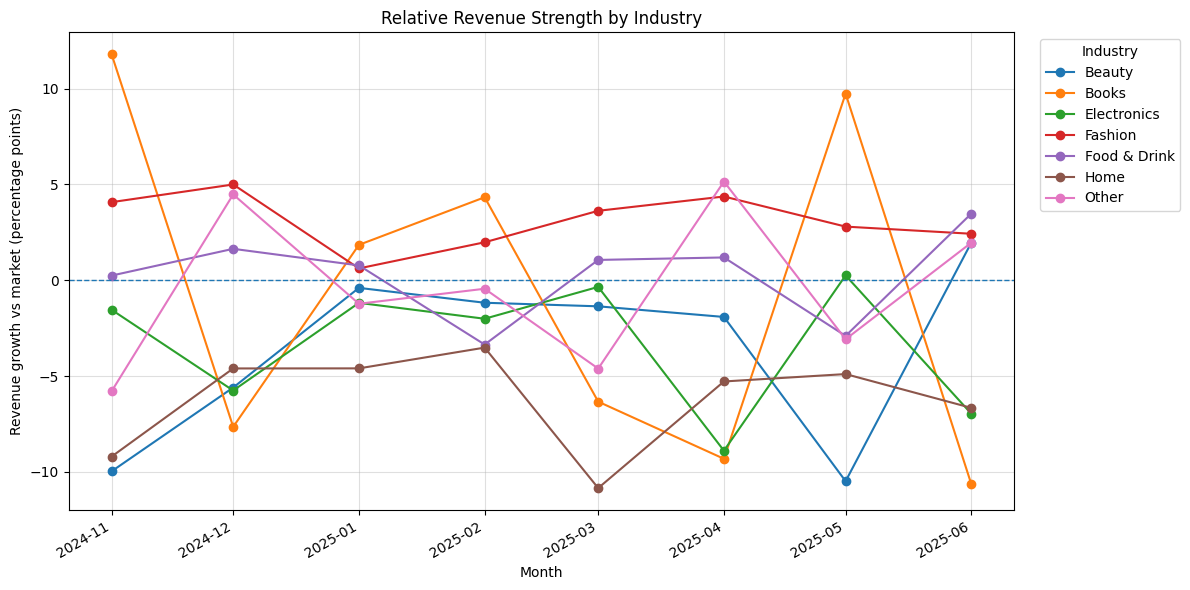

In [56]:
fig, ax = plt.subplots(figsize=(12, 6))

for industry, group in relative_industry.groupby("industry"):
    group = group.sort_values("month")
    ax.plot(group["month"], group["relative_revenue_strength_pct"], marker="o", label=industry)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Relative Revenue Strength by Industry")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue growth vs market (percentage points)")
ax.grid(True, alpha=0.4)
ax.legend(title="Industry", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 17. Plot relative volume strength by industry

This plot shows whether each industry is growing or declining faster than the market in delivery-volume terms.

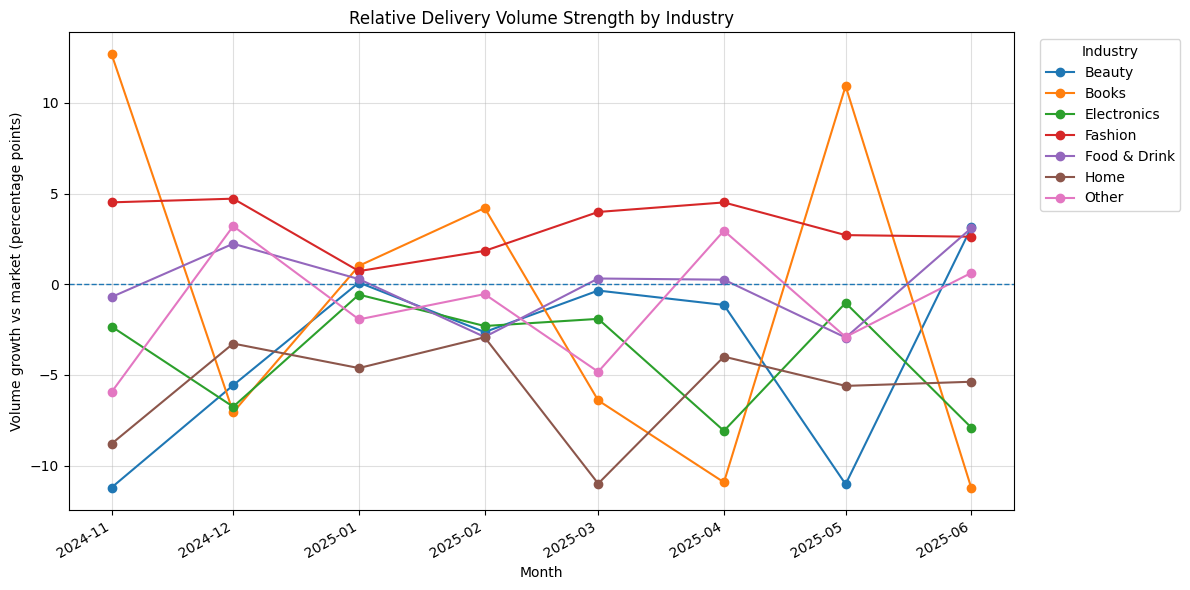

In [57]:
fig, ax = plt.subplots(figsize=(12, 6))

for industry, group in relative_industry.groupby("industry"):
    group = group.sort_values("month")
    ax.plot(group["month"], group["relative_volume_strength_pct"], marker="o", label=industry)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Relative Delivery Volume Strength by Industry")
ax.set_xlabel("Month")
ax.set_ylabel("Volume growth vs market (percentage points)")
ax.grid(True, alpha=0.4)
ax.legend(title="Industry", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 18. Interpretation guidance for relative industry plots

Use the plots as follows:

1. **Revenue/volume share plots** show whether an industry is taking a larger or smaller share of UrbanShift activity over time.
2. **Relative strength plots** show whether an industry is moving better or worse than the total market month-to-month.
3. If all industries decline together but shares stay stable, the movement is likely business-wide rather than industry-specific.
4. If one industry loses share or shows negative relative strength repeatedly, that industry may have a specific retention or demand issue.
5. These visuals support using a relative churn target because they show why absolute decline alone can confuse general market movement with customer-specific weakness.

## 19. Executive dashboard (key seasonality insights)

This dashboard combines the most important charts from the relative industry section into a single view:

1. Revenue share trend for the highest-share industries.
2. Delivery volume share trend for the highest-share industries.
3. Latest-month relative revenue strength by industry.
4. Latest-month relative volume strength by industry.

Use this as a concise summary slide for reporting and stakeholder discussion.

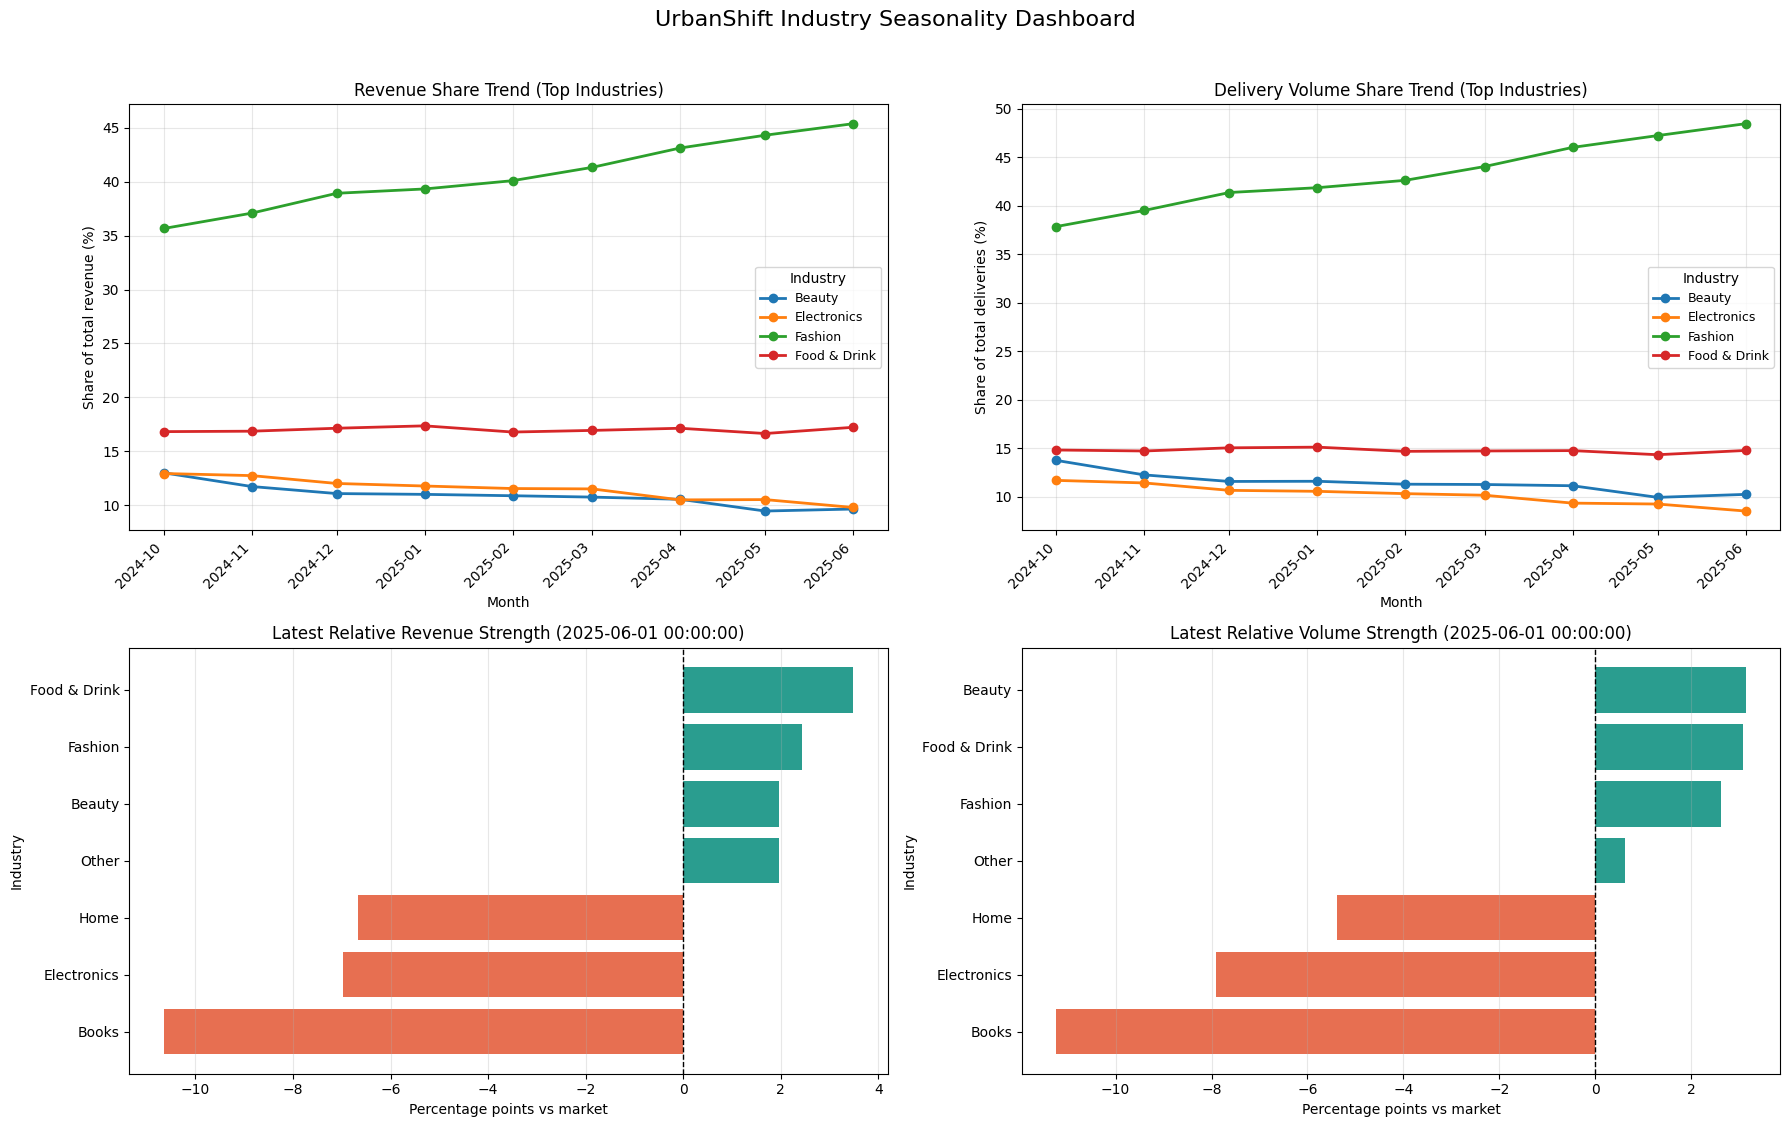

Latest dashboard month: 2025-06-01 00:00:00


,industry,revenue_share_pct,volume_share_pct,relative_revenue_strength_pct,relative_volume_strength_pct
0,Fashion,45.37,48.46,+2.43,+2.62
1,Food & Drink,17.23,14.75,+3.48,+3.09
2,Electronics,9.80,8.50,-6.97,-7.90
3,Beauty,9.66,10.22,+1.97,+3.14
4,Books,7.86,8.39,-10.65,-11.24
5,Other,6.04,5.50,+1.96,+0.63
6,Home,4.04,4.17,-6.66,-5.37


In [58]:
# Build a compact dashboard from the key relative-industry views.
if relative_industry.empty:
    print("relative_industry is empty. Run the previous section cells first.")
else:
    dashboard_df = relative_industry.sort_values(["industry", "month"]).copy()

    # Focus trend lines on the largest industries by average revenue share.
    top_n = min(4, dashboard_df["industry"].nunique())
    top_industries = (
        dashboard_df
        .groupby("industry")["revenue_share_pct"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )

    trend_df = dashboard_df[dashboard_df["industry"].isin(top_industries)].copy()
    latest_month = dashboard_df["month"].max()
    latest_df = dashboard_df[dashboard_df["month"] == latest_month].copy()

    fig, axes = plt.subplots(2, 2, figsize=(18, 11))

    # 1) Revenue share trend.
    for industry, group in trend_df.groupby("industry"):
        group = group.sort_values("month")
        axes[0, 0].plot(group["month"], group["revenue_share_pct"], marker="o", linewidth=2, label=industry)
    axes[0, 0].set_title("Revenue Share Trend (Top Industries)")
    axes[0, 0].set_xlabel("Month")
    axes[0, 0].set_ylabel("Share of total revenue (%)")
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend(title="Industry", fontsize=9)

    # 2) Volume share trend.
    for industry, group in trend_df.groupby("industry"):
        group = group.sort_values("month")
        axes[0, 1].plot(group["month"], group["volume_share_pct"], marker="o", linewidth=2, label=industry)
    axes[0, 1].set_title("Delivery Volume Share Trend (Top Industries)")
    axes[0, 1].set_xlabel("Month")
    axes[0, 1].set_ylabel("Share of total deliveries (%)")
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend(title="Industry", fontsize=9)

    # 3) Latest-month relative revenue strength.
    latest_revenue_rank = latest_df.sort_values("relative_revenue_strength_pct", ascending=True)
    axes[1, 0].barh(
        latest_revenue_rank["industry"],
        latest_revenue_rank["relative_revenue_strength_pct"],
        color=np.where(latest_revenue_rank["relative_revenue_strength_pct"] >= 0, "#2a9d8f", "#e76f51")
    )
    axes[1, 0].axvline(0, linestyle="--", linewidth=1, color="black")
    axes[1, 0].set_title(f"Latest Relative Revenue Strength ({latest_month})")
    axes[1, 0].set_xlabel("Percentage points vs market")
    axes[1, 0].set_ylabel("Industry")
    axes[1, 0].grid(True, axis="x", alpha=0.3)

    # 4) Latest-month relative volume strength.
    latest_volume_rank = latest_df.sort_values("relative_volume_strength_pct", ascending=True)
    axes[1, 1].barh(
        latest_volume_rank["industry"],
        latest_volume_rank["relative_volume_strength_pct"],
        color=np.where(latest_volume_rank["relative_volume_strength_pct"] >= 0, "#2a9d8f", "#e76f51")
    )
    axes[1, 1].axvline(0, linestyle="--", linewidth=1, color="black")
    axes[1, 1].set_title(f"Latest Relative Volume Strength ({latest_month})")
    axes[1, 1].set_xlabel("Percentage points vs market")
    axes[1, 1].set_ylabel("Industry")
    axes[1, 1].grid(True, axis="x", alpha=0.3)

    for ax in [axes[0, 0], axes[0, 1]]:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_ha("right")

    fig.suptitle("UrbanShift Industry Seasonality Dashboard", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    # Add a compact latest-month KPI table for quick reporting.
    latest_kpi = latest_df[[
        "industry",
        "revenue_share_pct",
        "volume_share_pct",
        "relative_revenue_strength_pct",
        "relative_volume_strength_pct",
    ]].copy()
    latest_kpi = latest_kpi.sort_values("revenue_share_pct", ascending=False).reset_index(drop=True)

    print(f"Latest dashboard month: {latest_month}")
    display(latest_kpi.style.format({
        "revenue_share_pct": "{:.2f}",
        "volume_share_pct": "{:.2f}",
        "relative_revenue_strength_pct": "{:+.2f}",
        "relative_volume_strength_pct": "{:+.2f}",
    }))